# Battery charge and discharge analysis

This notebook documents the battery charge and discharge measurements used to derive battery-related control parameters for the Energy Management System (EMS). The analysis processes measured current, voltage, and power data from full charge and discharge tests and evaluates the usable battery capacity and state of charge (SoC) behaviour.

## Data and method

The input data consists of INA226 logs from battery charge and discharge tests. The notebook cleans the timestamps and numeric channels, selects the active charge and discharge regions, integrates current and power over time, and recalculates SoC from measured ampere-hours and watt-hours.

The first part of the notebook is used to inspect the measured battery behaviour and compare the integrated usable capacity with the nominal battery values.

## Relevance for the EMS

The EMS uses a scaled demonstration battery model rather than the full physical battery capacity. The measured discharge energy is therefore used as a reference for scaling the battery energy to the EMS demonstration size and for extracting a voltage-to-SoC lookup curve.

C:\Users\matil\AppData\Local\Temp\ipykernel_31156\2368156557.py:99: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt_s.iloc[0] = 0
C:\Users\matil\AppData\Local\Temp\ipykernel_31156\2368156557.py:99: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt_s.iloc[0] = 0



Measured reference capacity from discharge test
--------------------------------------------------
Measured usable capacity: 2.1288 Ah
Measured usable energy:   8.0464 Wh
Nominal capacity:         2.0000 Ah
Nominal energy:           7.4000 Wh

Charge dataset
--------------------------------------------------
Charge duration:          8.585 h
Integrated charge:        2.1480 Ah
Integrated charge energy: 9.1382 Wh
Final SoC from Ah:        100.90 %
Final SoC from Wh:        110.00 %

Discharge dataset
--------------------------------------------------
Discharge duration:          13.150 h
Integrated discharged Ah:    2.1288 Ah
Integrated discharged Wh:    8.0464 Wh
Final SoC from Ah:           0.00 %
Final SoC from Wh:           0.00 %


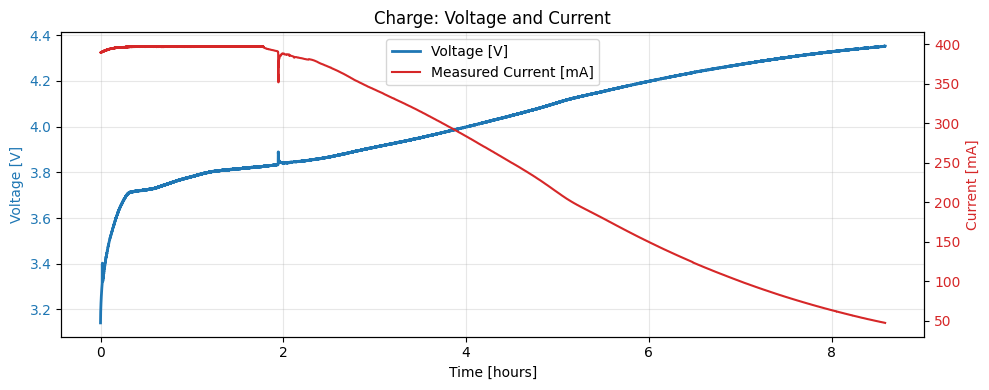

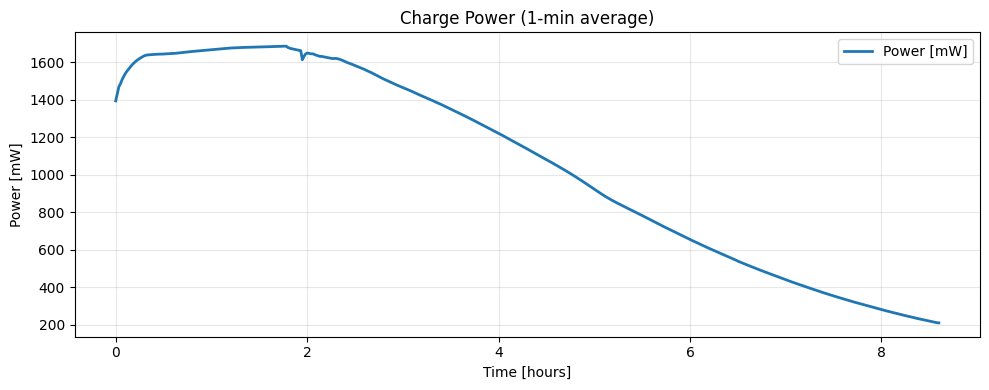

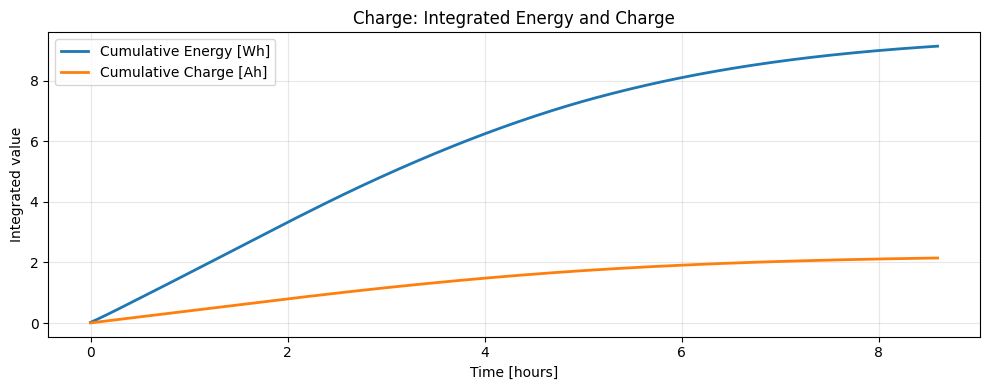

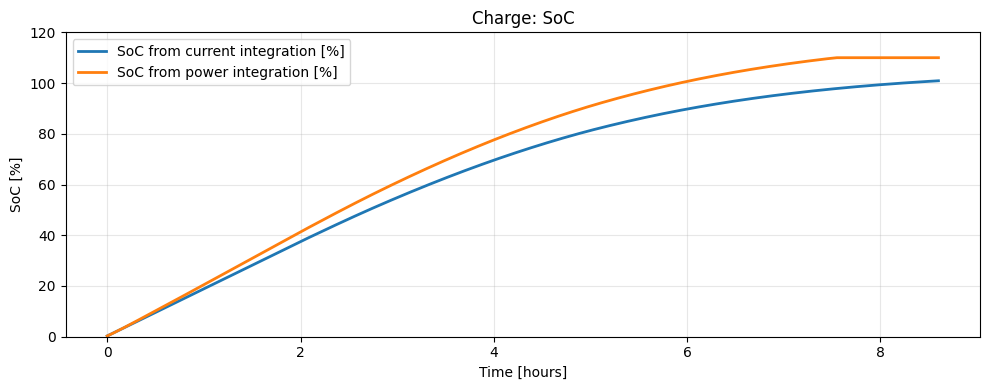

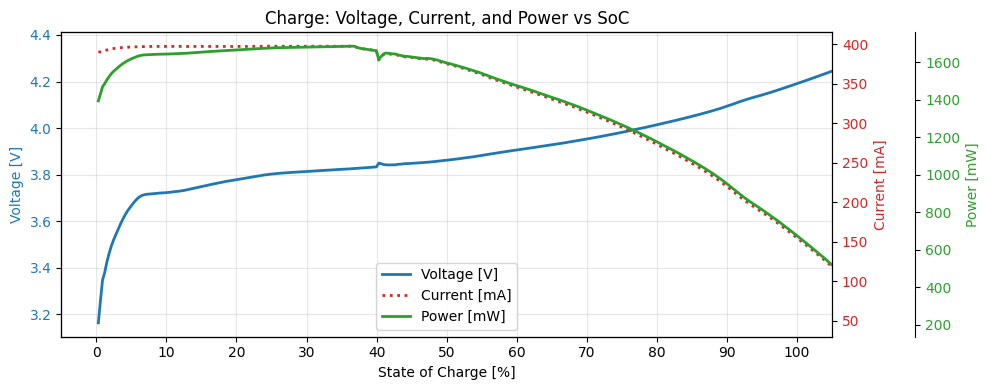

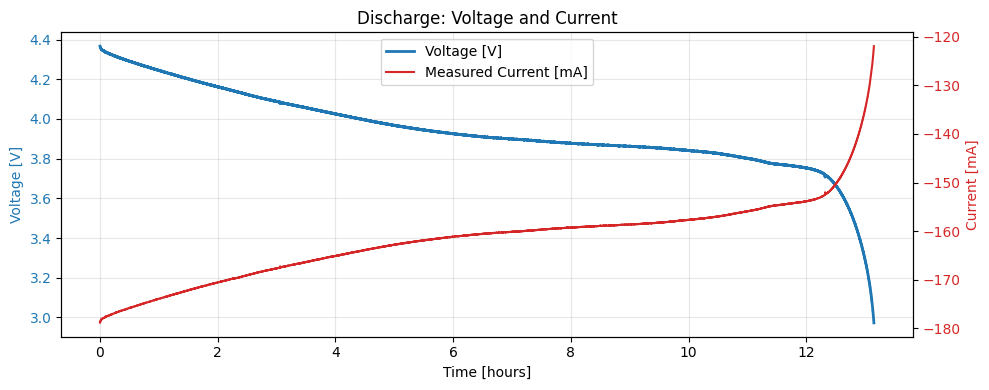

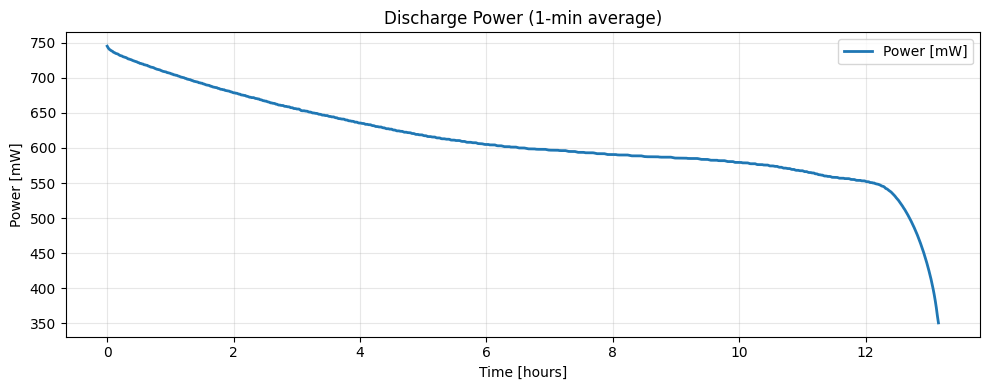

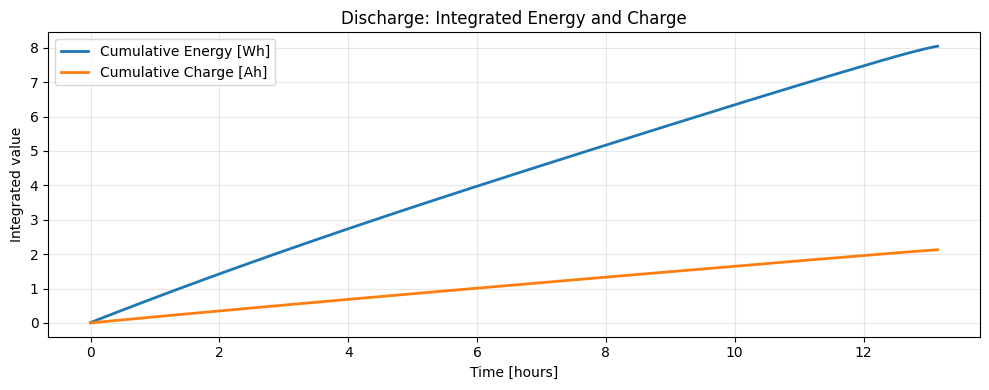

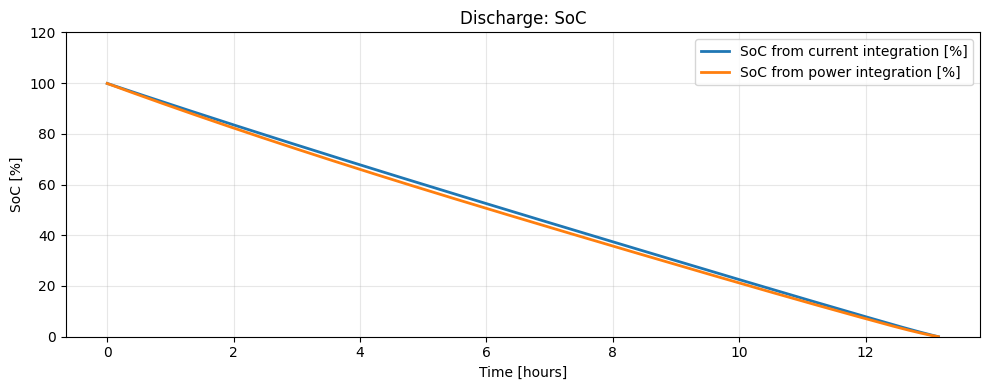

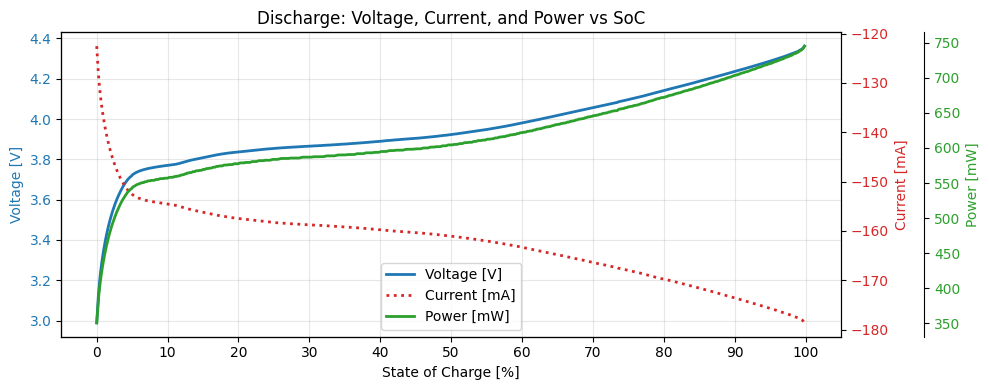

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Settings
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the project root folder containing data/")
    PROJECT_ROOT = PROJECT_ROOT.parent

charge_file = PROJECT_ROOT / "data/Battery_test/BATTERY_CHARGE_ina226_soc_log_20260420_180900.csv"
discharge_file = PROJECT_ROOT / "data/Battery_test/BATTERY_DISCHARGE_ina226_soc_log_20260421_095715.csv"

resample_interval = "1min"
charge_threshold_mA = 10.0
discharge_threshold_mA = -10.0

# Optional nominal values for comparison only
battery_nominal_Ah = 2.0
battery_nominal_Wh = 7.4


# Helpers
def load_and_clean(csv_file):
    df = pd.read_csv(csv_file)

    df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")
    df = df.dropna(subset=["pc_time"]).copy()
    df = df.sort_values("pc_time").reset_index(drop=True)
    df = df.drop_duplicates(subset="pc_time", keep="first").copy()

    numeric_cols = [
        "elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV",
        "voltage_corrected_V", "soc_voltage_percent", "soc_percent"
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "mode" in df.columns:
        df["mode"] = df["mode"].astype(str).str.strip().str.upper()

    df = df.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()
    return df


def extract_active_block(df, target_mode):
    if "mode" in df.columns and (df["mode"] == target_mode).any():
        is_active = df["mode"] == target_mode
    else:
        if target_mode == "CHARGE":
            is_active = df["current_mA"] > charge_threshold_mA
        elif target_mode == "DISCHARGE":
            is_active = df["current_mA"] < discharge_threshold_mA
        else:
            raise ValueError(f"Unsupported target_mode: {target_mode}")

    if not is_active.any():
        raise ValueError(f"No rows found for mode {target_mode}")

    start_idx = is_active.idxmax()
    df_after_start = df.loc[start_idx:].copy()

    if "mode" in df.columns and (df_after_start["mode"] == target_mode).any():
        is_active_after = df_after_start["mode"] == target_mode
    else:
        if target_mode == "CHARGE":
            is_active_after = df_after_start["current_mA"] > charge_threshold_mA
        else:
            is_active_after = df_after_start["current_mA"] < discharge_threshold_mA

    stop_candidates = df_after_start.index[~is_active_after]

    if len(stop_candidates) > 0:
        stop_idx = stop_candidates[0]
        df_block = df.loc[start_idx:stop_idx - 1].copy()
    else:
        df_block = df.loc[start_idx:].copy()

    if df_block.empty:
        raise ValueError(f"Filtered dataframe is empty for mode {target_mode}")

    return df_block


def prepare_block(df_block, mode_name, resample_interval="1min"):
    df_plot = df_block.copy()

    # Relative time
    df_plot["t_hours"] = (
        df_plot["pc_time"] - df_plot["pc_time"].iloc[0]
    ).dt.total_seconds() / 3600.0

    # dt
    dt_s = df_plot["pc_time"].diff().dt.total_seconds()
    dt_s.iloc[0] = 0
    dt_s = dt_s.clip(lower=0, upper=10)
    df_plot["dt_s"] = dt_s
    df_plot["dt_h"] = df_plot["dt_s"] / 3600.0

    # Active current / power as positive quantities
    if mode_name == "CHARGE":
        df_plot["active_current_mA"] = df_plot["current_mA"].clip(lower=0)
        df_plot["active_power_mW"] = df_plot["power_mW"].clip(lower=0)
    elif mode_name == "DISCHARGE":
        df_plot["active_current_mA"] = (-df_plot["current_mA"]).clip(lower=0)
        df_plot["active_power_mW"] = df_plot["power_mW"].abs()
    else:
        raise ValueError("mode_name must be CHARGE or DISCHARGE")

    df_plot["active_current_A"] = df_plot["active_current_mA"] / 1000.0
    df_plot["active_power_W"] = df_plot["active_power_mW"] / 1000.0

    # Incremental Ah / Wh
    df_plot["dQ_Ah"] = df_plot["active_current_A"] * df_plot["dt_h"]
    df_plot["dE_Wh"] = df_plot["active_power_W"] * df_plot["dt_h"]

    df_plot["cum_Ah"] = df_plot["dQ_Ah"].cumsum()
    df_plot["cum_Wh"] = df_plot["dE_Wh"].cumsum()

    # Resample
    df_min = df_plot.set_index("pc_time").resample(resample_interval).mean(numeric_only=True)
    df_min = df_min.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()
    df_min["t_hours"] = (df_min.index - df_min.index[0]).total_seconds() / 3600.0

    dt_resample_h = pd.to_timedelta(resample_interval).total_seconds() / 3600.0

    if mode_name == "CHARGE":
        df_min["active_current_mA"] = df_min["current_mA"].clip(lower=0)
        df_min["active_power_mW"] = df_min["power_mW"].clip(lower=0)
    else:
        df_min["active_current_mA"] = (-df_min["current_mA"]).clip(lower=0)
        df_min["active_power_mW"] = df_min["power_mW"].abs()

    df_min["active_current_A"] = df_min["active_current_mA"] / 1000.0
    df_min["active_power_W"] = df_min["active_power_mW"] / 1000.0

    df_min["dQ_Ah"] = df_min["active_current_A"] * dt_resample_h
    df_min["dE_Wh"] = df_min["active_power_W"] * dt_resample_h

    df_min["cum_Ah"] = df_min["dQ_Ah"].cumsum()
    df_min["cum_Wh"] = df_min["dE_Wh"].cumsum()

    return df_plot, df_min


def add_soc_columns(df_min, mode_name, reference_Ah, reference_Wh):
    df_min = df_min.copy()

    # Coulomb-counted SoC
    if mode_name == "CHARGE":
        df_min["soc_from_Ah"] = 100 * df_min["cum_Ah"] / reference_Ah
        df_min["soc_from_Wh"] = 100 * df_min["cum_Wh"] / reference_Wh
    else:
        df_min["soc_from_Ah"] = 100 * (1 - df_min["cum_Ah"] / reference_Ah)
        df_min["soc_from_Wh"] = 100 * (1 - df_min["cum_Wh"] / reference_Wh)

    df_min["soc_from_Ah"] = df_min["soc_from_Ah"].clip(0, 110)
    df_min["soc_from_Wh"] = df_min["soc_from_Wh"].clip(0, 110)

    return df_min


def plot_time_series(df_plot, mode_name):
    fig, ax1 = plt.subplots(figsize=(10, 4))

    y_voltage = "voltage_corrected_V" if "voltage_corrected_V" in df_plot.columns else "bus_V"

    ax1.plot(
        df_plot["t_hours"],
        df_plot[y_voltage],
        color="tab:blue",
        linewidth=2,
        label="Voltage [V]"
    )
    ax1.set_xlabel("Time [hours]")
    ax1.set_ylabel("Voltage [V]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        df_plot["t_hours"],
        df_plot["current_mA"],
        color="tab:red",
        linewidth=1.5,
        label="Measured Current [mA]"
    )
    ax2.set_ylabel("Current [mA]", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax1.set_title(f"{mode_name.title()}: Voltage and Current")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center")
    plt.tight_layout()


def plot_power_energy(df_min, mode_name):
    plt.figure(figsize=(10, 4))
    plt.plot(df_min["t_hours"], df_min["active_power_mW"], linewidth=2, label="Power [mW]")
    plt.xlabel("Time [hours]")
    plt.ylabel("Power [mW]")
    plt.title(f"{mode_name.title()} Power (1-min average)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.figure(figsize=(10, 4))
    plt.plot(df_min["t_hours"], df_min["cum_Wh"], linewidth=2, label="Cumulative Energy [Wh]")
    plt.plot(df_min["t_hours"], df_min["cum_Ah"], linewidth=2, label="Cumulative Charge [Ah]")
    plt.xlabel("Time [hours]")
    plt.ylabel("Integrated value")
    plt.title(f"{mode_name.title()}: Integrated Energy and Charge")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()


def plot_soc(df_min, mode_name):
    plt.figure(figsize=(10, 4))
    plt.plot(df_min["t_hours"], df_min["soc_from_Ah"], linewidth=2, label="SoC from current integration [%]")
    plt.plot(df_min["t_hours"], df_min["soc_from_Wh"], linewidth=2, label="SoC from power integration [%]")
    plt.xlabel("Time [hours]")
    plt.ylabel("SoC [%]")
    plt.title(f"{mode_name.title()}: SoC")
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 120)
    plt.legend()
    plt.tight_layout()


def plot_vs_soc(df_min, mode_name):
    soc_plot = df_min.dropna(subset=["soc_from_Wh", "bus_V", "current_mA", "active_power_mW"]).copy()
    soc_plot = soc_plot.sort_values("soc_from_Wh")

    y_voltage = "voltage_corrected_V" if "voltage_corrected_V" in soc_plot.columns else "bus_V"

    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.plot(
        soc_plot["soc_from_Wh"],
        soc_plot[y_voltage],
        color="tab:blue",
        linewidth=2,
        label="Voltage [V]"
    )
    ax1.set_xlabel("State of Charge [%]")
    ax1.set_ylabel("Voltage [V]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        soc_plot["soc_from_Wh"],
        soc_plot["current_mA"],
        color="tab:red",
        linestyle=":",
        linewidth=2,
        label="Current [mA]"
    )
    ax2.set_ylabel("Current [mA]", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))
    ax3.plot(
        soc_plot["soc_from_Wh"],
        soc_plot["active_power_mW"],
        color="tab:green",
        linewidth=2,
        label="Power [mW]"
    )
    ax3.set_ylabel("Power [mW]", color="tab:green")
    ax3.tick_params(axis="y", labelcolor="tab:green")

    ax1.set_xlim(-5, 105)
    ax1.set_xticks(np.arange(0, 101, 10))
    ax1.set_title(f"{mode_name.title()}: Voltage, Current, and Power vs SoC")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc="lower center")

    plt.tight_layout()


# Load and prepare both datasets
df_charge_raw = load_and_clean(charge_file)
df_discharge_raw = load_and_clean(discharge_file)

df_charge_block = extract_active_block(df_charge_raw, "CHARGE")
df_discharge_block = extract_active_block(df_discharge_raw, "DISCHARGE")

df_charge_plot, df_charge_min = prepare_block(df_charge_block, "CHARGE", resample_interval)
df_discharge_plot, df_discharge_min = prepare_block(df_discharge_block, "DISCHARGE", resample_interval)

# Define measured reference capacity from full discharge test
measured_capacity_Ah = df_discharge_min["cum_Ah"].iloc[-1]
measured_capacity_Wh = df_discharge_min["cum_Wh"].iloc[-1]

# Add recalculated SoC
df_charge_min = add_soc_columns(df_charge_min, "CHARGE", measured_capacity_Ah, measured_capacity_Wh)
df_discharge_min = add_soc_columns(df_discharge_min, "DISCHARGE", measured_capacity_Ah, measured_capacity_Wh)

# Print summary
print("\nMeasured reference capacity from discharge test")
print("--------------------------------------------------")
print(f"Measured usable capacity: {measured_capacity_Ah:.4f} Ah")
print(f"Measured usable energy:   {measured_capacity_Wh:.4f} Wh")
print(f"Nominal capacity:         {battery_nominal_Ah:.4f} Ah")
print(f"Nominal energy:           {battery_nominal_Wh:.4f} Wh")

print("\nCharge dataset")
print("--------------------------------------------------")
print(f"Charge duration:          {df_charge_plot['t_hours'].iloc[-1]:.3f} h")
print(f"Integrated charge:        {df_charge_min['cum_Ah'].iloc[-1]:.4f} Ah")
print(f"Integrated charge energy: {df_charge_min['cum_Wh'].iloc[-1]:.4f} Wh")
print(f"Final SoC from Ah:        {df_charge_min['soc_from_Ah'].iloc[-1]:.2f} %")
print(f"Final SoC from Wh:        {df_charge_min['soc_from_Wh'].iloc[-1]:.2f} %")

print("\nDischarge dataset")
print("--------------------------------------------------")
print(f"Discharge duration:          {df_discharge_plot['t_hours'].iloc[-1]:.3f} h")
print(f"Integrated discharged Ah:    {df_discharge_min['cum_Ah'].iloc[-1]:.4f} Ah")
print(f"Integrated discharged Wh:    {df_discharge_min['cum_Wh'].iloc[-1]:.4f} Wh")
print(f"Final SoC from Ah:           {df_discharge_min['soc_from_Ah'].iloc[-1]:.2f} %")
print(f"Final SoC from Wh:           {df_discharge_min['soc_from_Wh'].iloc[-1]:.2f} %")

# Plots
plot_time_series(df_charge_plot, "CHARGE")
plot_power_energy(df_charge_min, "CHARGE")
plot_soc(df_charge_min, "CHARGE")
plot_vs_soc(df_charge_min, "CHARGE")

plot_time_series(df_discharge_plot, "DISCHARGE")
plot_power_energy(df_discharge_min, "DISCHARGE")
plot_soc(df_discharge_min, "DISCHARGE")
plot_vs_soc(df_discharge_min, "DISCHARGE")

plt.show()

## EMS-scaled battery energy and voltage lookup table

The next section converts the measured discharge energy to the smaller EMS demonstration battery capacity. It then extracts charge and discharge voltage curves at selected SoC points, smooths the measured voltage data, and prints the lookup constants used by the EMS battery model.

,soc_percent,charge_voltage_V,discharge_voltage_V
0,0.0,3.215525,3.0198
1,2.0,3.518750,3.4680
2,5.0,3.690500,3.6993
3,10.0,3.726300,3.7658
4,15.0,3.759750,3.7999
5,20.0,3.790050,3.8314
6,30.0,3.819800,3.8628
7,40.0,3.848100,3.8838
8,50.0,3.887500,3.9151
9,60.0,3.939600,3.9672


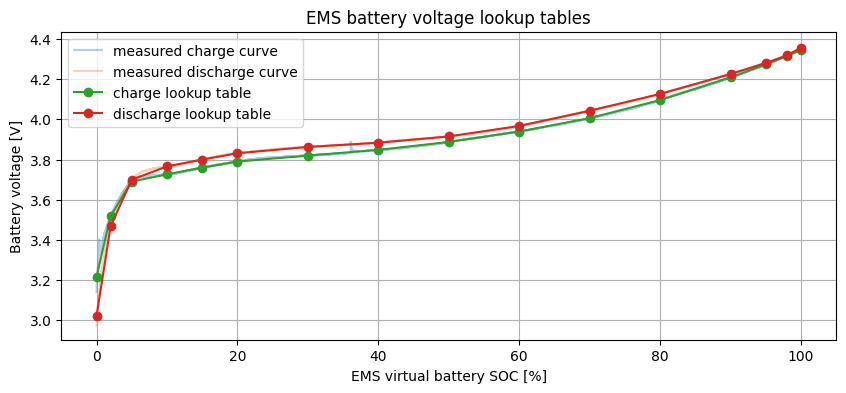

Copy these constants into the EMS battery model:

BATTERY_LOOKUP_SOC_PERCENT = (
    0.0,
    2.0,
    5.0,
    10.0,
    15.0,
    20.0,
    30.0,
    40.0,
    50.0,
    60.0,
    70.0,
    80.0,
    90.0,
    95.0,
    98.0,
    100.0,
)

BATTERY_CHARGE_VOLTAGE_LOOKUP_V = (
    3.2155,
    3.5187,
    3.6905,
    3.7263,
    3.7597,
    3.7900,
    3.8198,
    3.8481,
    3.8875,
    3.9396,
    4.0061,
    4.0962,
    4.2087,
    4.2733,
    4.3162,
    4.3462,
)

BATTERY_DISCHARGE_VOLTAGE_LOOKUP_V = (
    3.0198,
    3.4680,
    3.6993,
    3.7658,
    3.7999,
    3.8314,
    3.8628,
    3.8838,
    3.9151,
    3.9672,
    4.0429,
    4.1265,
    4.2257,
    4.2806,
    4.3184,
    4.3576,
)

Average voltage to SOC lookup table for EMS:

voltage_soc_curve: tuple[tuple[float, float], ...] = (
    (3.1177, 0.0),
    (3.4934, 2.0),
    (3.6949, 5.0),
    (3.7461, 10.0),
    (3.7798, 15.0),
    (3.8107, 20.0),
    (3.8413, 30.0),
    (3.8659, 40.0),
    (3.9013, 50.0),
    (3.9534, 60

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Find project root and load raw battery data

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the project root folder containing data/")
    PROJECT_ROOT = PROJECT_ROOT.parent

charge_file = PROJECT_ROOT / "data/Battery_test/BATTERY_CHARGE_ina226_soc_log_20260420_180900.csv"
discharge_file = PROJECT_ROOT / "data/Battery_test/BATTERY_DISCHARGE_ina226_soc_log_20260421_095715.csv"

charge_raw = pd.read_csv(charge_file)
discharge_raw = pd.read_csv(discharge_file)

# 2. Select active charge and discharge regions

charge = charge_raw[charge_raw["current_mA"] > 50].copy()
discharge = discharge_raw[discharge_raw["current_mA"] < -50].copy()

charge["time_min"] = (charge["elapsed_s"] - charge["elapsed_s"].iloc[0]) / 60
discharge["time_min"] = (discharge["elapsed_s"] - discharge["elapsed_s"].iloc[0]) / 60

# 3. Calculate discharge capacity and EMS scaled battery capacity

discharge["time_h"] = discharge["time_min"] / 60
discharge["dt_h"] = discharge["time_h"].diff().fillna(0)

discharge["discharge_current_A"] = -discharge["current_mA"] / 1000
discharge["discharge_power_W"] = (
    discharge["discharge_current_A"] * discharge["voltage_corrected_V"]
)

discharge["capacity_removed_Ah"] = (
    discharge["discharge_current_A"] * discharge["dt_h"]
).cumsum()

discharge["energy_removed_Wh"] = (
    discharge["discharge_power_W"] * discharge["dt_h"]
).cumsum()

MEASURED_BATTERY_ENERGY_WH = discharge["capacity_removed_Ah"].iloc[-1]

EMS_BATTERY_CAPACITY_MILLIWATT_HOUR = 10.0
EMS_BATTERY_CAPACITY_WH = EMS_BATTERY_CAPACITY_MILLIWATT_HOUR / 1000

BATTERY_ENERGY_SCALE_FACTOR = (
    EMS_BATTERY_CAPACITY_WH / MEASURED_BATTERY_ENERGY_WH
)

discharge["ems_energy_removed_mWh"] = (
    discharge["capacity_removed_Ah"] * BATTERY_ENERGY_SCALE_FACTOR * 1000
)

discharge["ems_energy_remaining_mWh"] = (
    EMS_BATTERY_CAPACITY_MILLIWATT_HOUR
    - discharge["ems_energy_removed_mWh"]
)

discharge["ems_energy_remaining_mWh"] = (
    discharge["ems_energy_remaining_mWh"].clip(0, EMS_BATTERY_CAPACITY_MILLIWATT_HOUR)
)

# 4. Extract voltage lookup tables

LOOKUP_SOC_POINTS = np.array(
    [0, 2, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 95, 98, 100],
    dtype=float,
)


def require_columns(df, required_columns, name):
    missing = [column for column in required_columns if column not in df.columns]

    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")


def prepare_charge_lookup_data(charge_df):
    curve = charge_df.copy()

    require_columns(
        curve,
        ["time_min", "current_mA", "voltage_corrected_V"],
        "charge",
    )

    curve["time_h"] = curve["time_min"] / 60.0
    curve["dt_h"] = curve["time_h"].diff().fillna(0).clip(lower=0)

    curve["charge_current_A"] = curve["current_mA"] / 1000.0
    curve["charge_power_W"] = (
        curve["charge_current_A"] * curve["voltage_corrected_V"]
    )

    curve["energy_added_Wh"] = (
        curve["charge_current_A"] * curve["dt_h"]
    ).cumsum()

    total_charge_energy_Wh = curve["energy_added_Wh"].iloc[-1]

    if total_charge_energy_Wh <= 0:
        raise ValueError("Total charge capacity is zero or negative. Check charge data.")

    curve["ems_energy_added_mWh"] = (
        curve["energy_added_Wh"] / total_charge_energy_Wh
    ) * EMS_BATTERY_CAPACITY_MILLIWATT_HOUR

    curve["lookup_soc_percent"] = (
        100.0
        * curve["ems_energy_added_mWh"]
        / EMS_BATTERY_CAPACITY_MILLIWATT_HOUR
    ).clip(0, 100)

    return curve


def prepare_discharge_lookup_data(discharge_df):
    curve = discharge_df.copy()

    require_columns(
        curve,
        ["voltage_corrected_V", "ems_energy_remaining_mWh"],
        "discharge",
    )

    curve["lookup_soc_percent"] = (
        100.0
        * curve["ems_energy_remaining_mWh"]
        / EMS_BATTERY_CAPACITY_MILLIWATT_HOUR
    ).clip(0, 100)

    return curve


def make_smoothed_voltage_curve(curve_df, soc_column, voltage_column):
    curve = curve_df[[soc_column, voltage_column]].dropna().copy()

    curve[soc_column] = curve[soc_column].clip(0, 100)
    curve = curve.sort_values(soc_column)

    curve["soc_bin"] = curve[soc_column].round(2)

    grouped = (
        curve.groupby("soc_bin", as_index=False)[voltage_column]
        .median()
        .rename(
            columns={
                "soc_bin": "soc_percent",
                voltage_column: "voltage_V",
            }
        )
    )

    grouped["voltage_smooth_V"] = (
        grouped["voltage_V"]
        .rolling(window=31, center=True, min_periods=1)
        .median()
    )

    return grouped


def interpolate_voltage_lookup(smoothed_curve, target_soc_points):
    x = smoothed_curve["soc_percent"].to_numpy(dtype=float)
    y = smoothed_curve["voltage_smooth_V"].to_numpy(dtype=float)

    return np.interp(target_soc_points, x, y)


charge_lookup_data = prepare_charge_lookup_data(charge)
discharge_lookup_data = prepare_discharge_lookup_data(discharge)

charge_curve = make_smoothed_voltage_curve(
    charge_lookup_data,
    soc_column="lookup_soc_percent",
    voltage_column="voltage_corrected_V",
)

discharge_curve = make_smoothed_voltage_curve(
    discharge_lookup_data,
    soc_column="lookup_soc_percent",
    voltage_column="voltage_corrected_V",
)

charge_voltage_lookup = interpolate_voltage_lookup(
    charge_curve,
    LOOKUP_SOC_POINTS,
)

discharge_voltage_lookup = interpolate_voltage_lookup(
    discharge_curve,
    LOOKUP_SOC_POINTS,
)

battery_lookup_table = pd.DataFrame(
    {
        "soc_percent": LOOKUP_SOC_POINTS,
        "charge_voltage_V": charge_voltage_lookup,
        "discharge_voltage_V": discharge_voltage_lookup,
    }
)

display(battery_lookup_table)

# 5. Plot lookup tables

plt.figure(figsize=(10, 4))

plt.plot(
    charge_lookup_data["lookup_soc_percent"],
    charge_lookup_data["voltage_corrected_V"],
    alpha=0.35,
    label="measured charge curve",
)

plt.plot(
    discharge_lookup_data["lookup_soc_percent"],
    discharge_lookup_data["voltage_corrected_V"],
    alpha=0.35,
    label="measured discharge curve",
)

plt.plot(
    LOOKUP_SOC_POINTS,
    charge_voltage_lookup,
    "o-",
    label="charge lookup table",
)

plt.plot(
    LOOKUP_SOC_POINTS,
    discharge_voltage_lookup,
    "o-",
    label="discharge lookup table",
)

plt.title("EMS battery voltage lookup tables")
plt.xlabel("EMS virtual battery SOC [%]")
plt.ylabel("Battery voltage [V]")
plt.grid(True)
plt.legend()
plt.show()

# 6. Print constants and save CSV

print("Copy these constants into the EMS battery model:")
print()

print("BATTERY_LOOKUP_SOC_PERCENT = (")
for value in LOOKUP_SOC_POINTS:
    print(f"    {value:.1f},")
print(")")
print()

print("BATTERY_CHARGE_VOLTAGE_LOOKUP_V = (")
for value in charge_voltage_lookup:
    print(f"    {value:.4f},")
print(")")
print()

print("BATTERY_DISCHARGE_VOLTAGE_LOOKUP_V = (")
for value in discharge_voltage_lookup:
    print(f"    {value:.4f},")
print(")")
print()

# 7. Average charge and discharge lookup and print as EMS tuple

battery_lookup_table["average_voltage_V"] = (
    battery_lookup_table["charge_voltage_V"]
    + battery_lookup_table["discharge_voltage_V"]
) / 2.0

average_voltage_soc_curve = tuple(
    (round(voltage, 4), round(soc, 1))
    for voltage, soc in zip(
        battery_lookup_table["average_voltage_V"],
        battery_lookup_table["soc_percent"],
    )
)

print("Average voltage to SOC lookup table for EMS:")
print()
print("voltage_soc_curve: tuple[tuple[float, float], ...] = (")

for voltage, soc in average_voltage_soc_curve:
    print(f"    ({voltage:.4f}, {soc:.1f}),")

print(")")

This code generates an average between charge and discharge voltage for the lookup table in the ems. This value is used to estimate the SoC from the Voc. 

In [4]:

battery_lookup_table["average_voltage_V"] = (
    battery_lookup_table["charge_voltage_V"]
    + battery_lookup_table["discharge_voltage_V"]
) / 2.0

average_voltage_soc_curve = tuple(
    (round(voltage, 4), round(soc, 1))
    for voltage, soc in zip(
        battery_lookup_table["average_voltage_V"],
        battery_lookup_table["soc_percent"],
    )
)

print("Average voltage-to-SOC lookup table for EMS:")
print()
print("voltage_soc_curve: tuple[tuple[float, float], ...] = (")

for voltage, soc in average_voltage_soc_curve:
    print(f"    ({voltage:.4f}, {soc:.1f}),")

print(")")

Average voltage-to-SOC lookup table for EMS:

voltage_soc_curve: tuple[tuple[float, float], ...] = (
    (3.1177, 0.0),
    (3.4934, 2.0),
    (3.6949, 5.0),
    (3.7461, 10.0),
    (3.7798, 15.0),
    (3.8107, 20.0),
    (3.8413, 30.0),
    (3.8659, 40.0),
    (3.9013, 50.0),
    (3.9534, 60.0),
    (4.0245, 70.0),
    (4.1113, 80.0),
    (4.2172, 90.0),
    (4.2769, 95.0),
    (4.3173, 98.0),
    (4.3519, 100.0),
)


## Interpretation

The notebook uses the measured full discharge to estimate the usable battery capacity and energy. The charge and discharge curves are then translated to an EMS-scale battery model with a 10 mAh demonstration capacity.

The final voltage-to-SoC table averages the charge and discharge lookup voltages at selected SoC points. This gives the EMS a practical lookup curve for estimating battery SoC from measured voltage during operation.